# 🐶 Multi-Class Animal Image Classification using CNN

## Objective

In this notebook, we will build a **Convolutional Neural Network (CNN)** that can classify images of different animals.

This project demonstrates the complete Deep Learning workflow:

- Loading an image dataset
- Visualizing images
- Preprocessing data
- Building a CNN model
- Training the model
- Evaluating performance
- Predicting new images

Dataset:
Animals-10 (Kaggle)

Framework:
TensorFlow / Keras

In [1]:
import os

# Paste your username and API key here
os.environ['KAGGLE_USERNAME'] = "Harijith_03"
os.environ['KAGGLE_KEY'] = "KGAT_efdc0361d0e9a878749e93954188e105"

# Now run the command directly
!kaggle datasets download -d alessiocorrado99/animals10
!unzip -q animals10.zip -d ./dataset

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:28<00:00, 21.8MB/s]



In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
# Dataset location
DATASET = "/content/dataset/raw-img"

# Image dimensions
IMG_SIZE = (128,128)

# Number of images processed together
BATCH_SIZE = 32

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


# Display the Classes

Let's see what categories are present in our dataset.

In [5]:
class_names = train_ds.class_names

print("Animal Classes:\n")

for cls in class_names:
    print(cls)

print("\nTotal Classes:", len(class_names))

Animal Classes:

cane
cavallo
elefante
farfalla
gallina
gatto
mucca
pecora
ragno
scoiattolo

Total Classes: 10


In [6]:
italian_to_english = {
    "cane": "Dog",
    "cavallo": "Horse",
    "elefante": "Elephant",
    "farfalla": "Butterfly",
    "gallina": "Chicken",
    "gatto": "Cat",
    "mucca": "Cow",
    "pecora": "Sheep",
    "ragno": "Spider",
    "scoiattolo": "Squirrel"
}

In [7]:
class_names = train_ds.class_names

print("Animal Classes:\n")

for cls in class_names:
    print(italian_to_english[cls])

Animal Classes:

Dog
Horse
Elephant
Butterfly
Chicken
Cat
Cow
Sheep
Spider
Squirrel


# Visualize Sample Images

Before training, it's always a good practice to inspect the images.

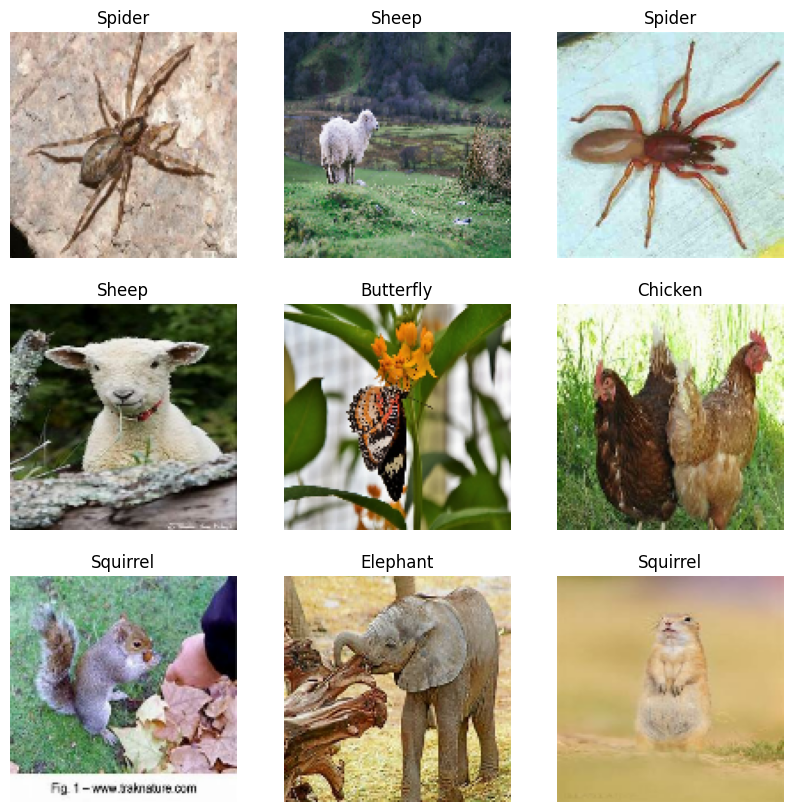

In [8]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(italian_to_english[class_names[labels[i]]])

        plt.axis("off")

plt.show()

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
model = tf.keras.Sequential([# Normalize pixel values (0-255 -> 0-1)
    tf.keras.layers.Rescaling(1./255),

    # First Convolution Block
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Second Convolution Block
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Third Convolution Block
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Convert feature maps into a 1D vector
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(256, activation='relu'),

    # Reduce overfitting
    tf.keras.layers.Dropout(0.3),

    # Output Layer
    tf.keras.layers.Dense(len(class_names), activation='softmax')

])

In [11]:
model.compile(optimizer='adam', loss ='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [12]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.3935 - loss: 1.7365 - val_accuracy: 0.5391 - val_loss: 1.3635
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.5794 - loss: 1.2395 - val_accuracy: 0.6264 - val_loss: 1.1447
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.6719 - loss: 0.9780 - val_accuracy: 0.6315 - val_loss: 1.1362
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7410 - loss: 0.7692 - val_accuracy: 0.6392 - val_loss: 1.1587
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - accuracy: 0.7996 - loss: 0.5944 - val_accuracy: 0.6636 - val_loss: 1.2074
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.8491 - loss: 0.4398 - val_accuracy: 0.6657 - val_loss: 1.4109
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.8824 - loss: 0.3416 - val_accuracy: 0.6575 - val_loss: 1.4283
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9095 - loss: 0.2620 - 

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,555,808 (74.60 MB)

 Trainable params: 6,518,602 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,037,206 (49.73 MB)

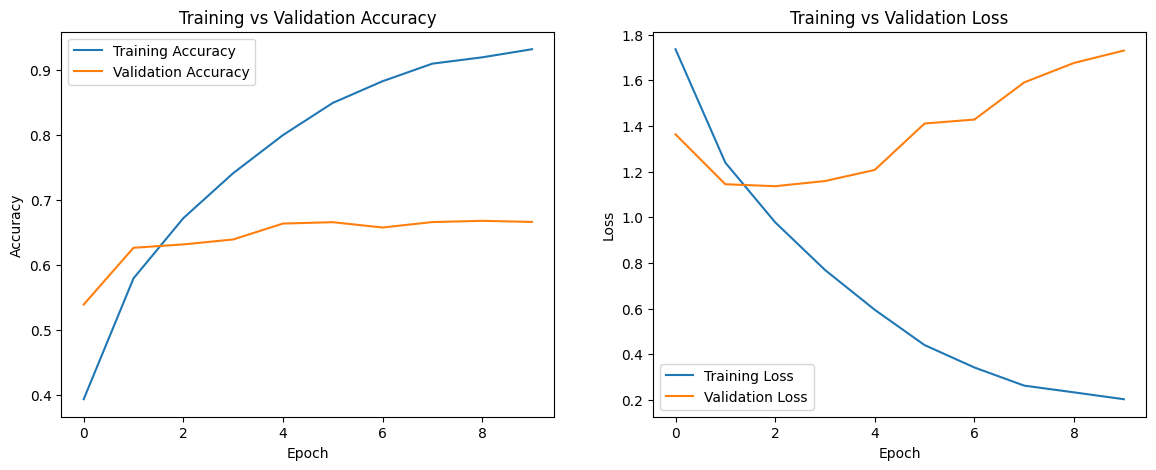

In [14]:
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step


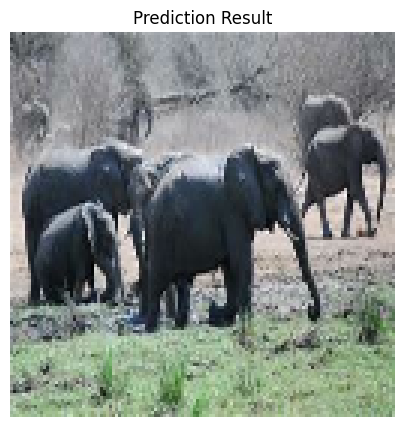

Actual Label    : Elephant
Predicted Label : Cow


In [15]:
for images, labels in val_ds.take(1):

    sample_image = images[0]

    actual_label = italian_to_english[class_names[labels[0]]]

    prediction = model.predict(tf.expand_dims(sample_image, axis=0))

    predicted_label = italian_to_english[class_names[np.argmax(prediction)]]

    plt.figure(figsize=(5,5))

    plt.imshow(sample_image.numpy().astype("uint8"))

    plt.axis("off")

    plt.title("Prediction Result")

    plt.show()

    print("Actual Label    :", actual_label)
    print("Predicted Label :", predicted_label)

# Reducing Overfitting

# Data Augmentation

Data augmentation artificially increases the diversity of the training dataset by applying random transformations to the images.

Examples include:
- Horizontal Flip
- Rotation
- Zoom
- Contrast Adjustment

In [16]:
# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)])

In [17]:
improved_model = tf.keras.Sequential([
    # Normalize pixel values
    tf.keras.layers.Rescaling(1./255),

    # Apply Data Augmentation
    data_augmentation,

    # First Convolution Block
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Second Convolution Block
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Third Convolution Block
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Flatten Feature Maps
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(256, activation="relu"),

    # Dropout Layer
    tf.keras.layers.Dropout(0.3),

    # Output Layer
    tf.keras.layers.Dense(len(class_names), activation="softmax")

])

In [18]:
improved_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [19]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
    restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
    factor=0.2, patience=2, min_lr=1e-6, verbose=1)

In [20]:
history_improved = improved_model.fit(train_ds, validation_data=val_ds, epochs=20,
    callbacks=[early_stopping, reduce_lr])

Epoch 1/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.3238 - loss: 1.9117 - val_accuracy: 0.3945 - val_loss: 1.7844 - learning_rate: 0.0010
Epoch 2/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.4630 - loss: 1.5614 - val_accuracy: 0.5629 - val_loss: 1.2967 - learning_rate: 0.0010
Epoch 3/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.5280 - loss: 1.3851 - val_accuracy: 0.5431 - val_loss: 1.3331 - learning_rate: 0.0010
Epoch 4/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.5526 - loss: 1.3043 - val_accuracy: 0.6069 - val_loss: 1.1647 - learning_rate: 0.0010
Epoch 5/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.5770 - loss: 1.2331 - val_accuracy: 0.6034 - val_loss: 1.1865 - learning_rate: 0.0010
Epoch 6/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.5948 - loss: 1.1823 - val_accuracy: 0.6166 - val_loss: 1.1271 - learning_rate: 0.0010
Epoch 7/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.6073 - l

In [21]:
improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,555,808 (74.60 MB)

 Trainable params: 6,518,602 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,037,206 (49.73 MB)

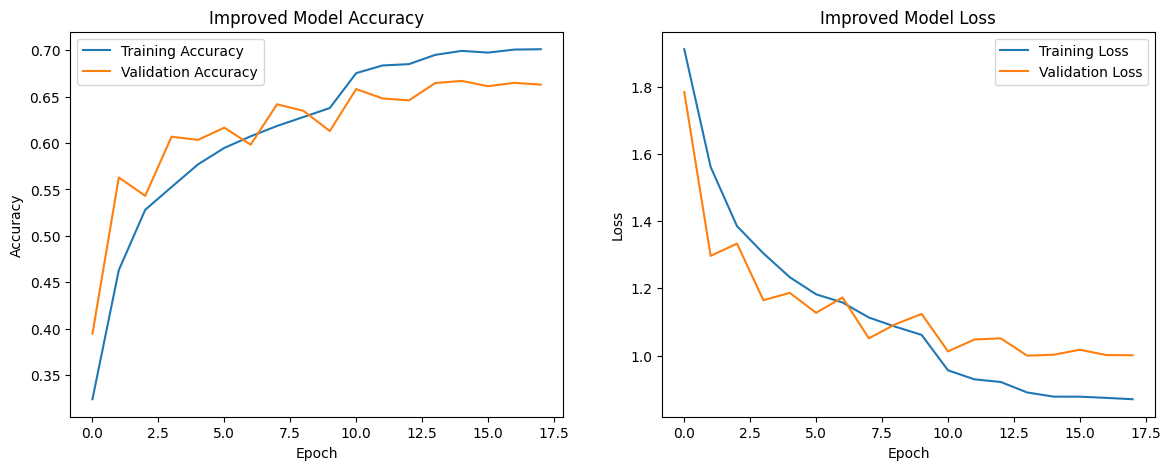

In [22]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_improved.history["accuracy"], label="Training Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.title("Improved Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_improved.history["loss"], label="Training Loss")
plt.plot(history_improved.history["val_loss"], label="Validation Loss")
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

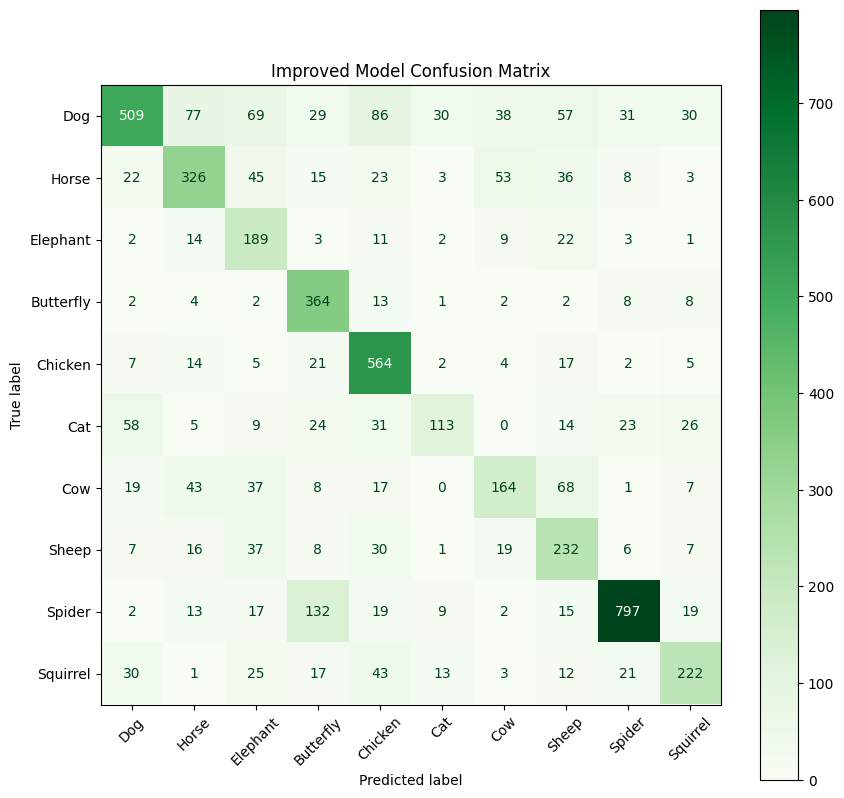

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []
english_class_names = [italian_to_english[name] for name in class_names]
for images, labels in val_ds:

    predictions = improved_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= english_class_names)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(cmap="Greens", xticks_rotation=45, ax=ax)
plt.title("Improved Model Confusion Matrix")
plt.show()

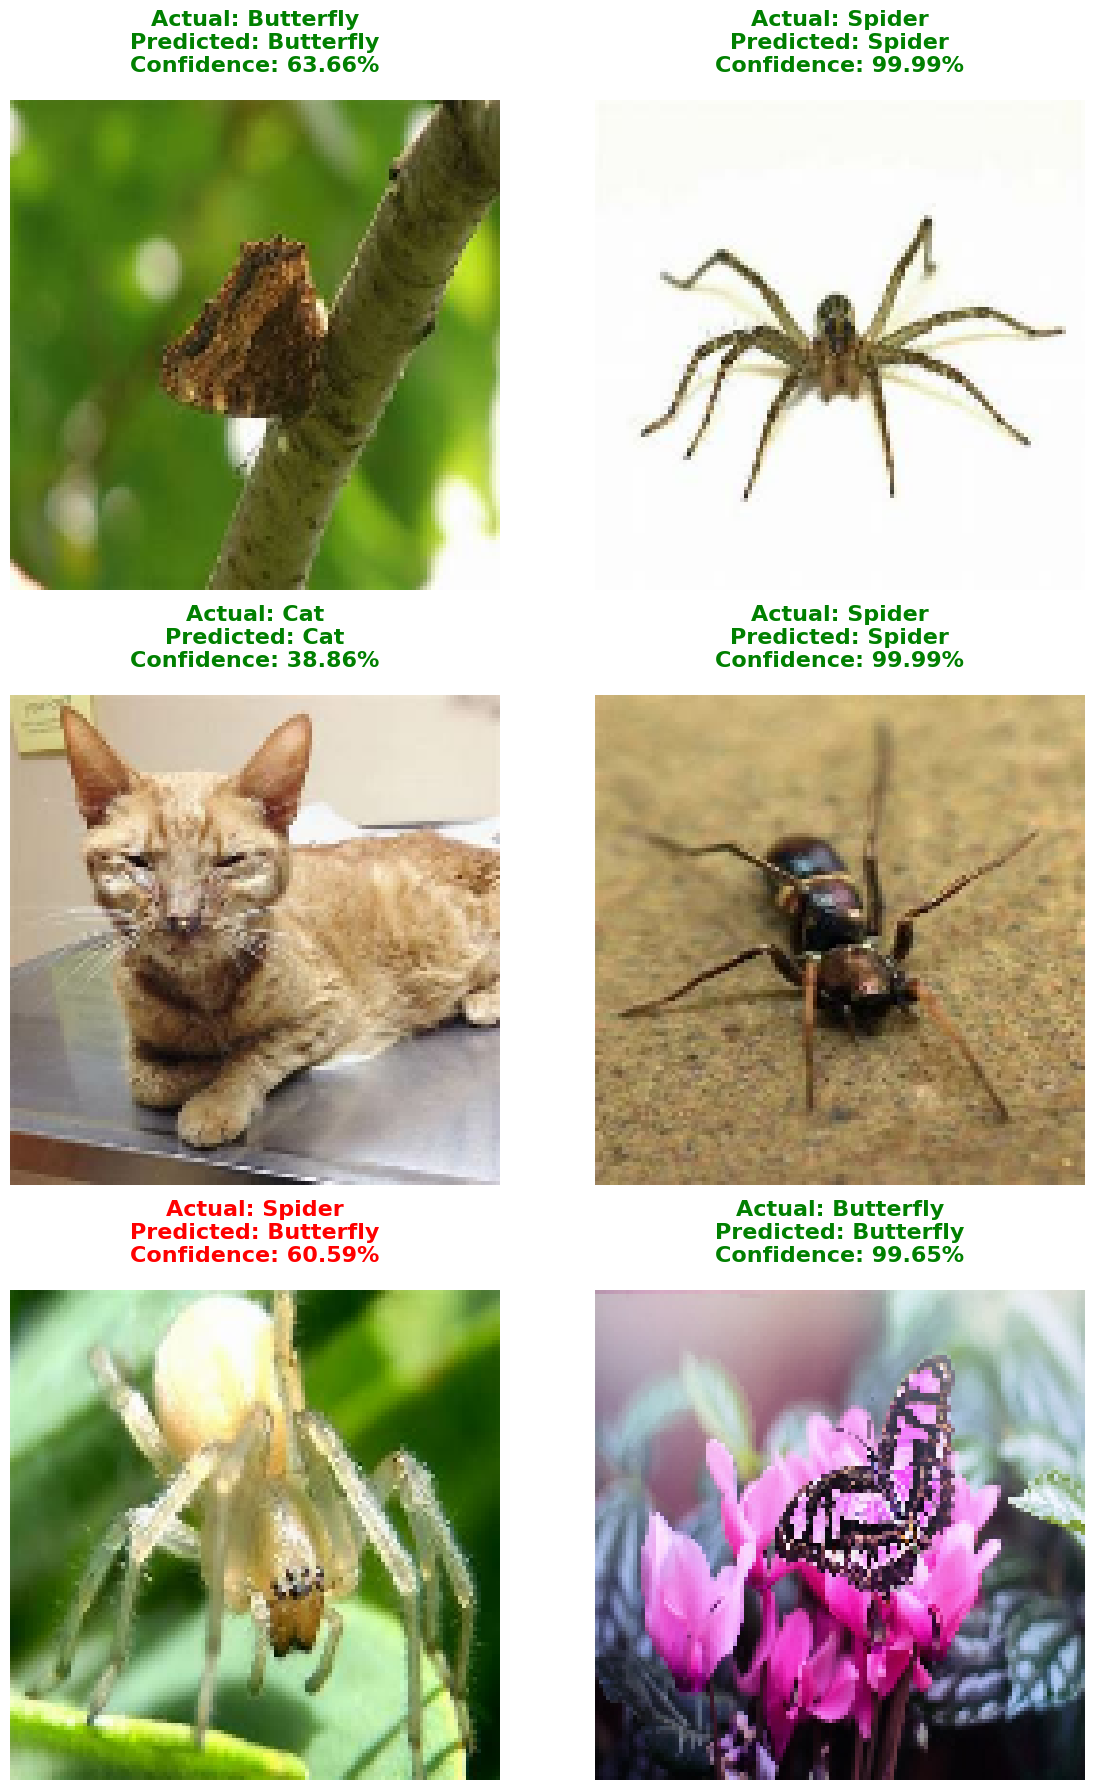

In [24]:
import random

# Store all validation images and labels
all_images = []
all_labels = []

for images, labels in val_ds:
    all_images.extend(images)
    all_labels.extend(labels.numpy())

# Randomly select 6 images
indices = random.sample(range(len(all_images)), 6)

# Create a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 18))

for ax, idx in zip(axes.flatten(), indices):

    image = all_images[idx]

    actual = english_class_names[all_labels[idx]]

    prediction = improved_model.predict(
        tf.expand_dims(image, 0),
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    predicted = english_class_names[predicted_index]

    confidence = prediction[predicted_index] * 100

    # Display image
    ax.imshow(image.numpy().astype("uint8"))
    ax.axis("off")

    # Green if correct, Red if incorrect
    color = "green" if actual == predicted else "red"

    ax.set_title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.2f}%",
        fontsize=16,
        fontweight="bold",
        color=color,
        pad=20
    )

plt.tight_layout()
plt.show()

In [25]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(128,128,3), include_top=False, weights="imagenet")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [26]:
base_model.trainable = False

In [27]:
transfer_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")])

In [28]:
transfer_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [29]:
history_transfer = transfer_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stopping, reduce_lr])

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7252 - loss: 0.8525 - val_accuracy: 0.9054 - val_loss: 0.3007 - learning_rate: 0.0010
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.8000 - loss: 0.6168 - val_accuracy: 0.9100 - val_loss: 0.2843 - learning_rate: 0.0010
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.8117 - loss: 0.5878 - val_accuracy: 0.9144 - val_loss: 0.2717 - learning_rate: 0.0010
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.8145 - loss: 0.5685 - val_accuracy: 0.9169 - val_loss: 0.2631 - learning_rate: 0.0010
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.8198 - loss: 0.5636 - val_accuracy: 0.9144 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8198 - loss: 0.5574
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.8189 - lo

In [30]:
transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,296,416 (8.76 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 25,622 (100.09 KB)

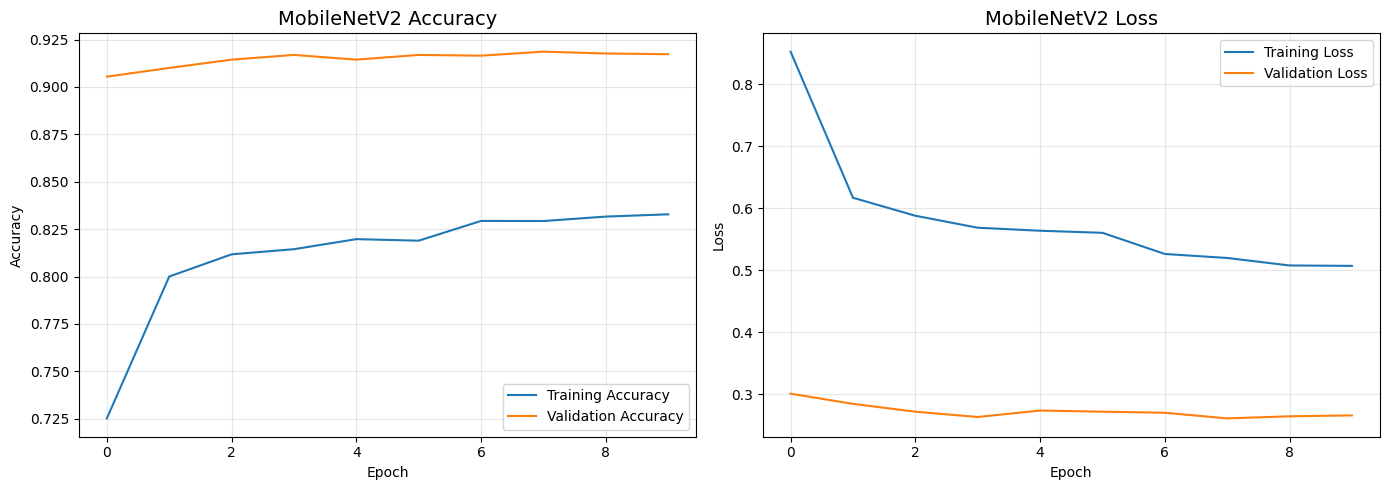

In [31]:
# Plot Accuracy and Loss Curves

plt.figure(figsize=(14, 5))

# -------------------------------
# Accuracy Plot
# -------------------------------
plt.subplot(1, 2, 1)

plt.plot(history_transfer.history["accuracy"], label="Training Accuracy")
plt.plot(history_transfer.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()


# -------------------------------
# Loss Plot
# -------------------------------
plt.subplot(1, 2, 2)

plt.plot(history_transfer.history["loss"], label="Training Loss")
plt.plot(history_transfer.history["val_loss"], label="Validation Loss")

plt.title("MobileNetV2 Loss", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.show()

In [32]:
val_loss, val_accuracy = transfer_model.evaluate(val_ds, verbose=1)

print(f"\nValidation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy*100:.2f}%")

164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9186 - loss: 0.2608

Validation Loss     : 0.2608
Validation Accuracy : 91.86%


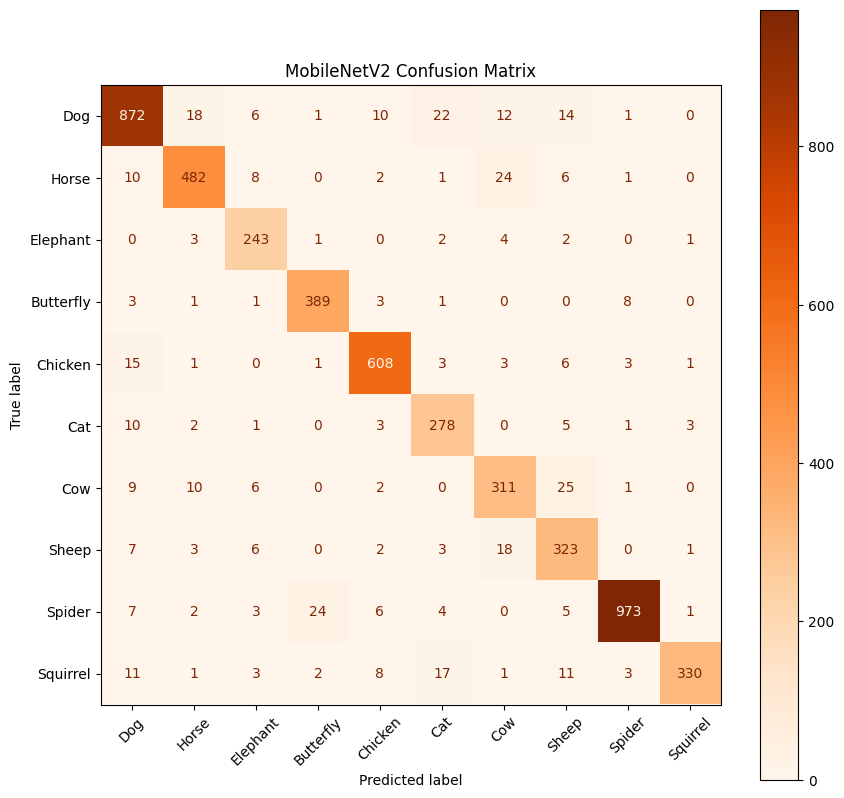

In [33]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = transfer_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=english_class_names)
fig, ax = plt.subplots(figsize=(10,10))

disp.plot(cmap="Oranges", xticks_rotation=45, ax=ax)
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

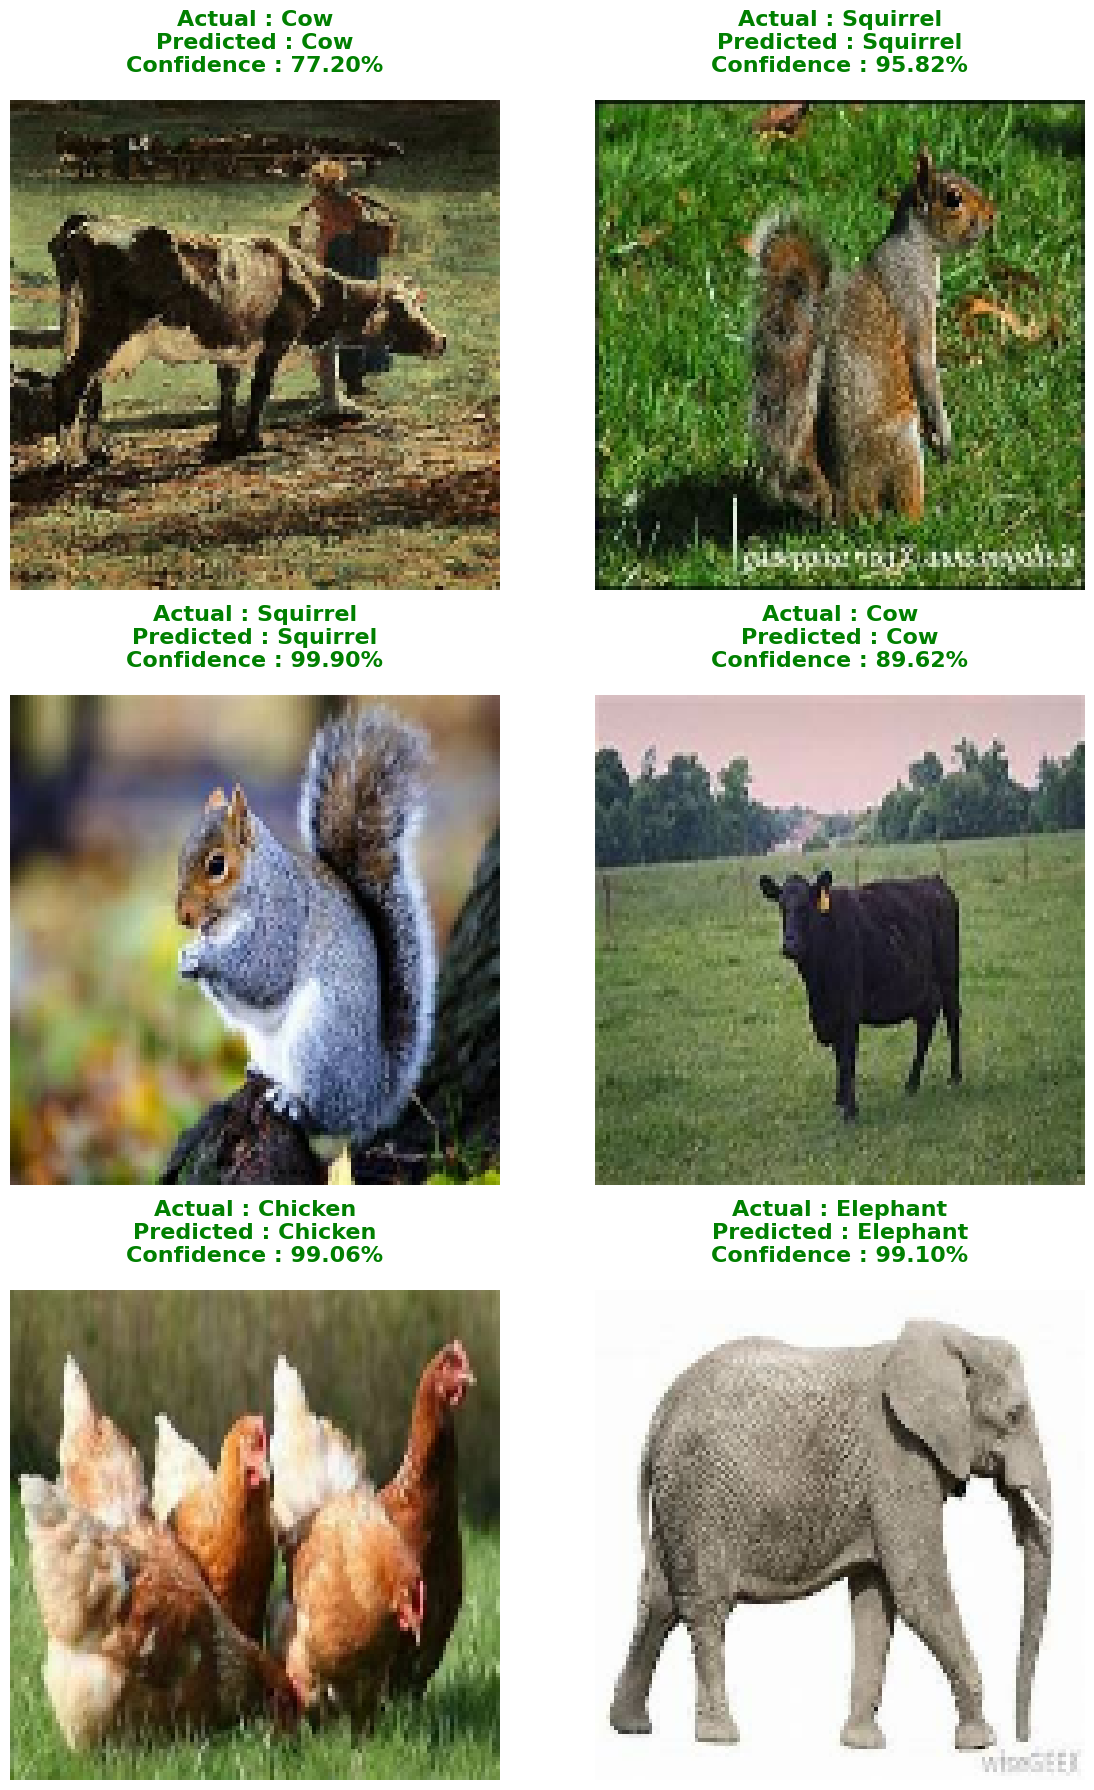

In [34]:
import random

all_images = []
all_labels = []

for images, labels in val_ds:
    all_images.extend(images)
    all_labels.extend(labels.numpy())

indices = random.sample(range(len(all_images)), 6)
fig, axes = plt.subplots(3, 2, figsize=(12,18))

for ax, idx in zip(axes.flatten(), indices):
    image = all_images[idx]
    actual = english_class_names[all_labels[idx]]

    prediction = transfer_model.predict(tf.expand_dims(image,0), verbose=0)[0]
    predicted_index = np.argmax(prediction)
    predicted = english_class_names[predicted_index]
    confidence = prediction[predicted_index] * 100
    ax.imshow(image.numpy().astype("uint8"))

    ax.axis("off")

    color = "green" if actual == predicted else "red"

    ax.set_title(
        f"Actual : {actual}\n"
        f"Predicted : {predicted}\n"
        f"Confidence : {confidence:.2f}%",
        fontsize=16,
        fontweight="bold",
        color=color,
        pad=20)

plt.tight_layout()
plt.show()

In [35]:
strong_cnn = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255),

    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(32, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.20),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(64, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(128, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

In [36]:
strong_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [37]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1)

checkpoint = tf.keras.callbacks.ModelCheckpoint("best_strong_cnn.keras", monitor="val_accuracy", save_best_only=True, verbose=1)

In [38]:
history_strong = strong_cnn.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[early_stopping, reduce_lr, checkpoint])

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.2720 - loss: 2.0529
Epoch 1: val_accuracy improved from None to 0.25540, saving model to best_strong_cnn.keras

Epoch 1: finished saving model to best_strong_cnn.keras
655/655 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.3217 - loss: 1.9276 - val_accuracy: 0.2554 - val_loss: 2.8602 - learning_rate: 0.0010
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3969 - loss: 1.7250
Epoch 2: val_accuracy improved from 0.25540 to 0.36638, saving model to best_strong_cnn.keras

Epoch 2: finished saving model to best_strong_cnn.keras
655/655 ━━━━━━━━━━━━━━━━━━━━ 78s 112ms/step - accuracy: 0.4145 - loss: 1.6715 - val_accuracy: 0.3664 - val_loss: 1.9100 - learning_rate: 0.0010
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4605 - loss: 1.5483
Epoch 3: val_accuracy improved from 0.36638 to 0.40191, saving model to best_strong_cnn.keras

Epoch 3: finished saving model to best_strong_cnn.kera

In [39]:
strong_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 971,392 (3.71 MB)

 Trainable params: 323,498 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 646,998 (2.47 MB)

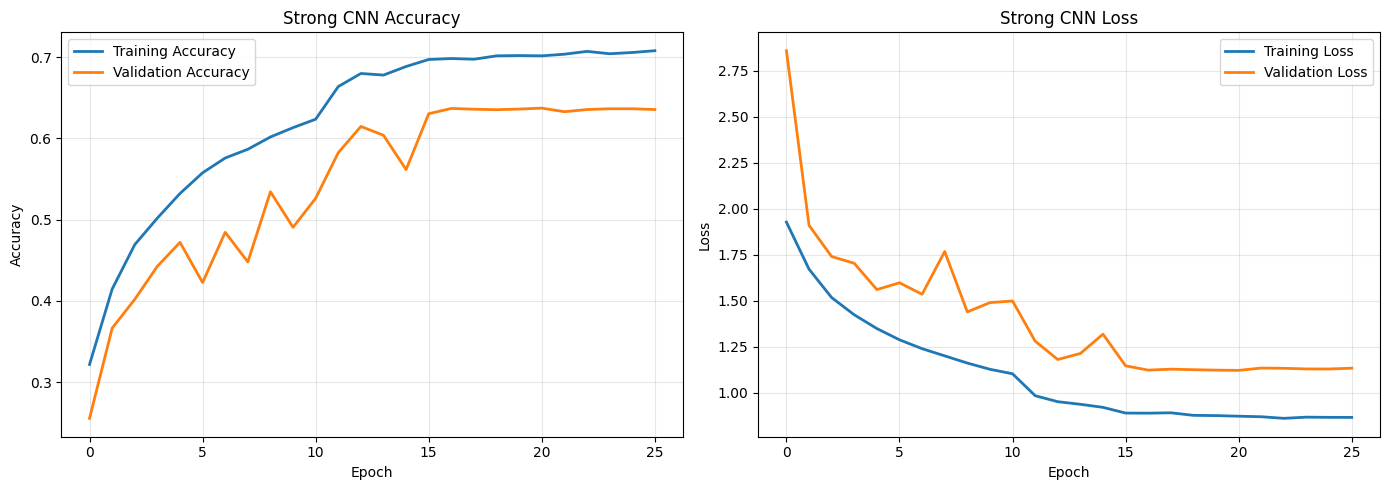

In [40]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history_strong.history["accuracy"], linewidth=2, label="Training Accuracy")
plt.plot(history_strong.history["val_accuracy"], linewidth=2, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Strong CNN Accuracy")
plt.grid(alpha=0.3)

plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(history_strong.history["loss"], linewidth=2, label="Training Loss")
plt.plot(history_strong.history["val_loss"], linewidth=2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Strong CNN Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
loss, accuracy = strong_cnn.evaluate(val_ds)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")

164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6372 - loss: 1.1208
Validation Loss     : 1.1208
Validation Accuracy : 63.72%


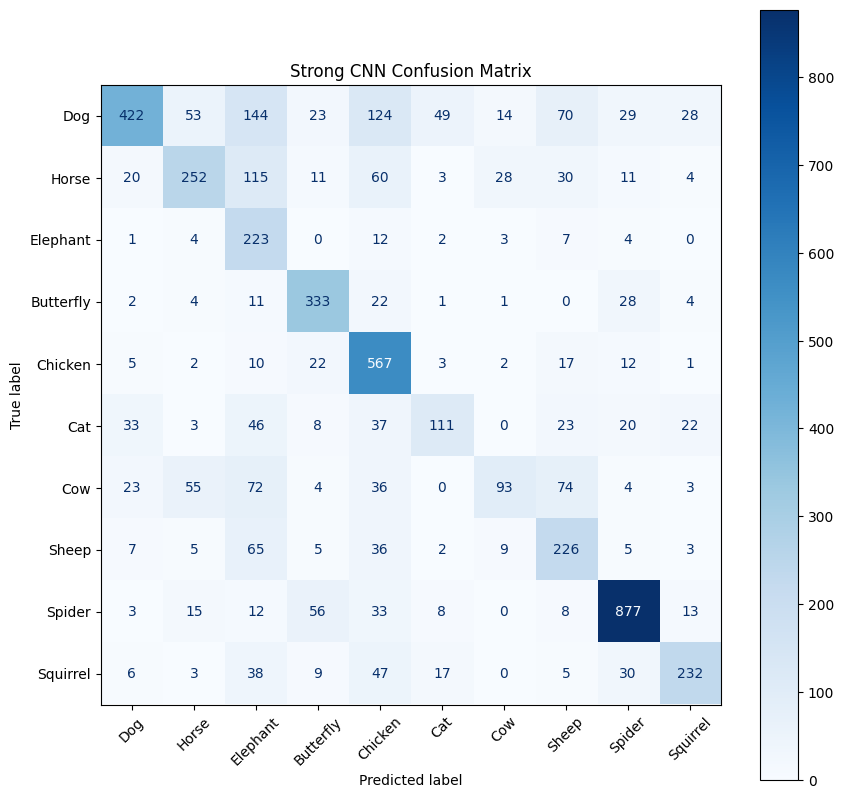

In [42]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = strong_cnn.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=english_class_names

)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.title("Strong CNN Confusion Matrix")

plt.show()

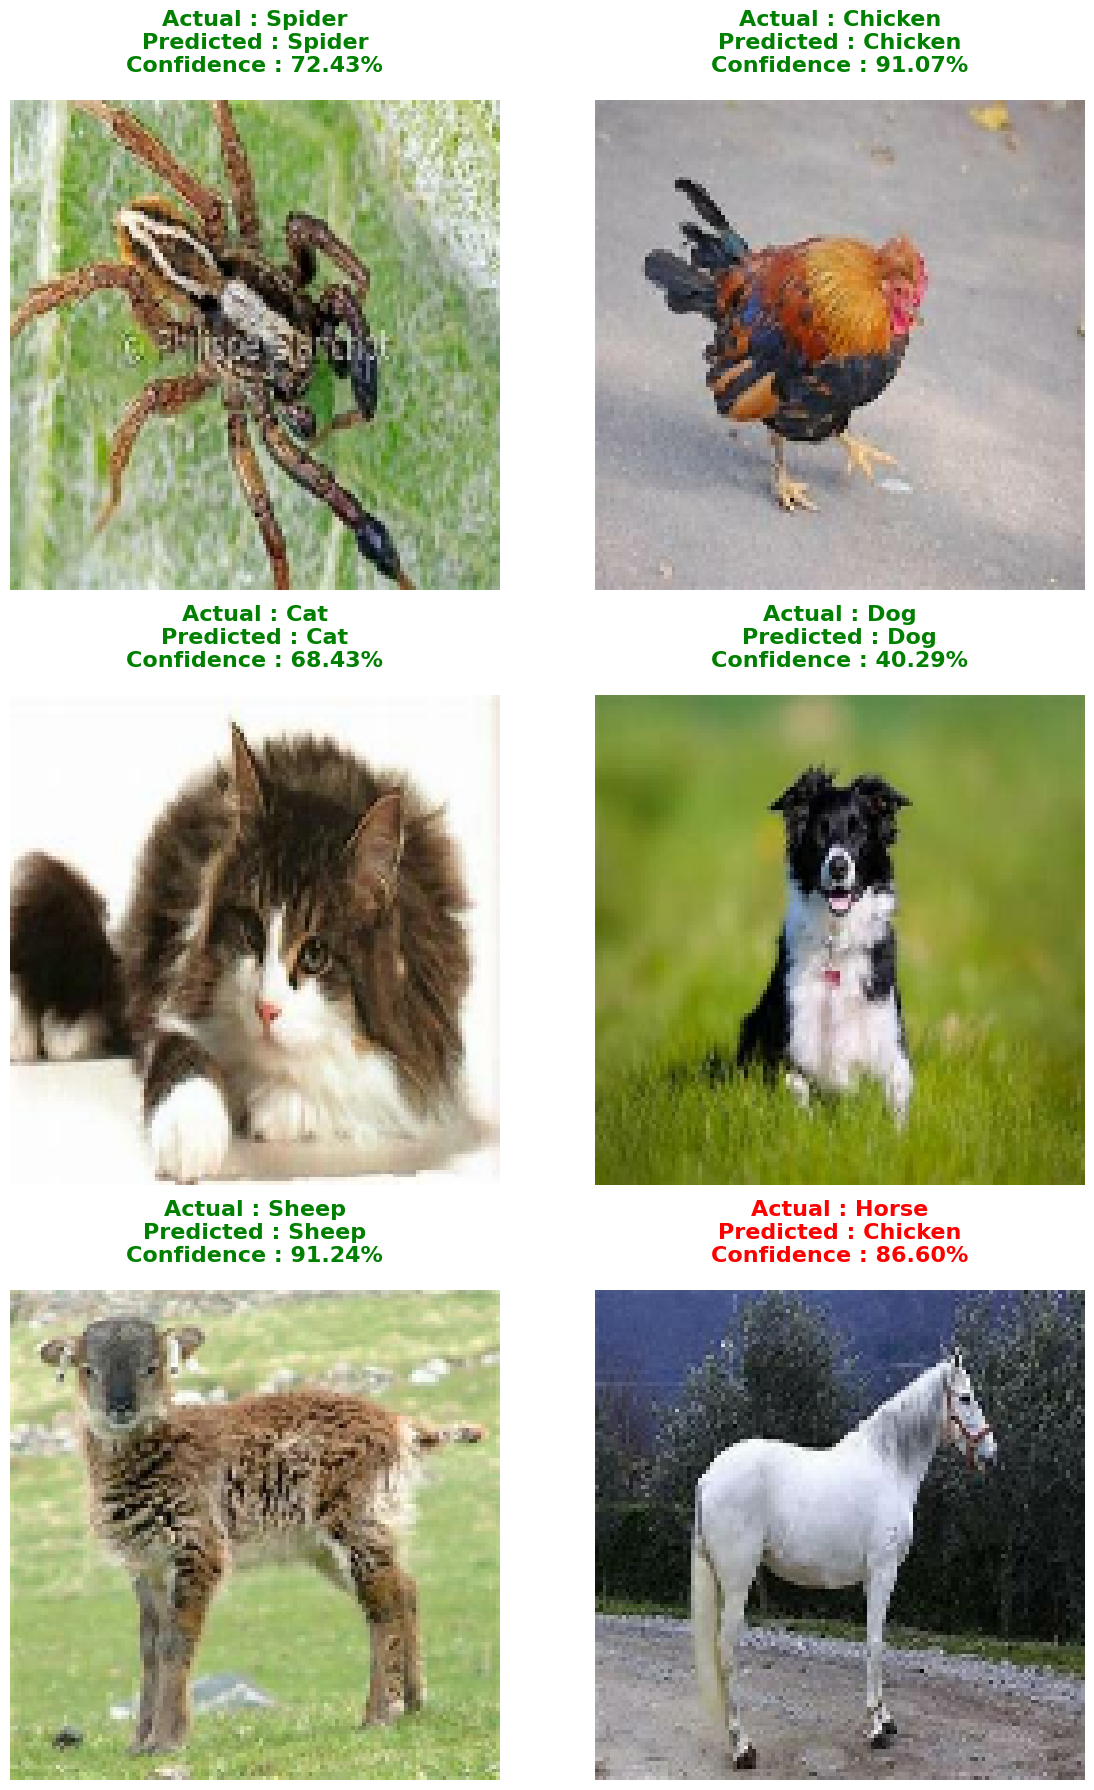

In [43]:
import random

all_images = []
all_labels = []

for images, labels in val_ds:

    all_images.extend(images)

    all_labels.extend(labels.numpy())

indices = random.sample(
    range(len(all_images)),
    6
)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12,18)
)

for ax, idx in zip(axes.flatten(), indices):

    image = all_images[idx]

    actual = english_class_names[
        all_labels[idx]
    ]

    prediction = strong_cnn.predict(
        tf.expand_dims(image,0),
        verbose=0
    )[0]

    predicted = english_class_names[
        np.argmax(prediction)
    ]

    confidence = np.max(prediction)*100

    color = "green" if actual==predicted else "red"

    ax.imshow(
        image.numpy().astype("uint8")
    )

    ax.axis("off")

    ax.set_title(

        f"Actual : {actual}\n"
        f"Predicted : {predicted}\n"
        f"Confidence : {confidence:.2f}%",

        fontsize=16,

        fontweight="bold",

        color=color,

        pad=20

    )

plt.tight_layout()

plt.show()